In [2]:
pip install pandas numpy matplotlib scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pandas in c:\users\likhi\anaconda3\lib\site-packages (2.2.3)



In [ ]:
pip install pandas numpy matplotlib scikit-learn jupyter

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
target = 'SalePrice'
x= df[features]
y= df[target]

In [8]:
x.isnull().sum()

GrLivArea       0
BedroomAbvGr    0
FullBath        0
dtype: int64

In [21]:
#Split Dataset
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [22]:
#Train Linear Regression model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [23]:
#predict
y_pred = model.predict(x_test)

In [24]:
#Evaluate model mean absolute error
mea = mean_absolute_error(y_test, y_pred)
print("MAE:", mea)

MAE: 35788.0612924363


In [25]:
#mean squared error
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 2806426667.247853


In [26]:
#root mean squared error
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 52975.71771338122


In [27]:
#R^2 score
r2= r2_score(y_test, y_pred)
print("R^2 score:", r2)

R^2 score: 0.6341189942328371


In [28]:
#model coefficients
print("intercept:", model.intercept_)
coeff = pd.DataFrame({'Feature': x.columns, 'coefficient': model.coef_})
print(coeff)

intercept: 52261.74862694461
        Feature   coefficient
0     GrLivArea    104.026307
1  BedroomAbvGr -26655.165357
2      FullBath  30014.324109


In [29]:
#Interpretation:

#Every extra square foot increases price by approximately $104.026307.
#Every extra bathroom increases price by approximately $30014.324109.
#The bedroom coefficient may be negative due to correlation with house size and other feature. 

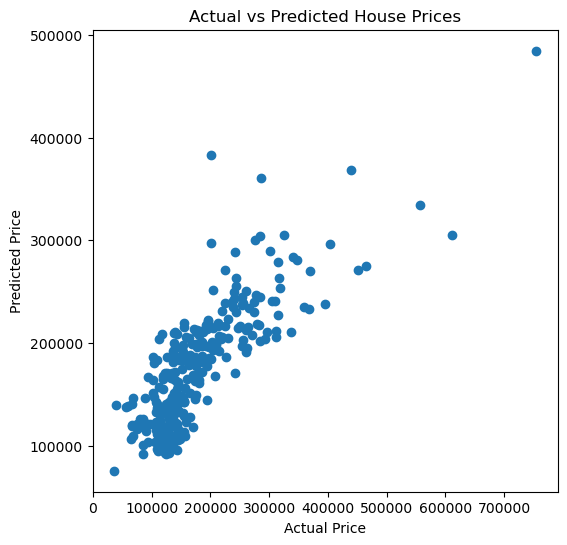

In [30]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [32]:
#predict your own house
house = pd.DataFrame({ 'GrLivArea' : [2000], 'BedroomAbvGr' : [3], 'FullBath' : 2})

prediction = model.predict(house)

print("Predicted Price:", prediction[0])

Predicted Price: 240377.51479736282
